# Webpage tree

The idea is to build a hierarchical tree representation of depth n for each website. Each node is a square that represents a certain area, such as the header. Then, we can always find both parent and children for each node, where the children should always be contained in area of their parent.

In [1]:
import json
from copy import deepcopy
from itertools import combinations
import cv2
import numpy as np
import matplotlib.pyplot as plt
from bs4 import BeautifulSoup

In [15]:
html_file = '../datasets/wl_data/demonstrations/dpftfrs/pages/page-1-0.html'
bb_file = '../datasets/wl_data/demonstrations/dpftfrs/bboxes/bboxes-1.json'
screenshot_file = '../datasets/wl_data/demonstrations/dpftfrs/screenshots/screenshot-1-0.png'

with open(html_file) as f:
    html_content = f.read()
soup = BeautifulSoup(html_content, 'html.parser')
with open(bb_file) as f:
    bboxes = json.load(f)

In [23]:
len(bboxes)

143

In [16]:
# access html head
soup.head

# access html body
soup.body
''

''

In [17]:
soup.head.find_all("title")

[<title data-webtasks-id="283aa074-b3bd-40cc">Quandoo - Over 17,000 restaurants worldwide. Book your table</title>]

# Build high and low level bounding boxes by their size 

In [18]:
# this value is the size of the screenshot, should be read dynamically ideally
im_size = 2667798

for bb in bboxes.values():
    w, h = bb['right'] - bb['left'], bb['bottom'] - bb['top']
    area = w * h
    bb['area'] = area

max_area = im_size

big_bbs = {}
small_bbs = {}
for k, bb in bboxes.items():
    if bb['area'] < max_area // 15:
        small_bbs[k] = bb
    else:
        if bb['area'] < im_size:
            big_bbs[k] = bb

In [19]:
# check overlapping area, take smallest possible bbs that cover most area
def get_overlap_area(r1, r2):
    """Calculate the overlapping area of two rectangles given their coordinates."""
    top = max(r1['top'], r2['top'])
    bottom = min(r1['bottom'], r2['bottom'])
    left = max(r1['left'], r2['left'])
    right = min(r1['right'], r2['right'])

    # If there is no overlap
    if top >= bottom or left >= right:
        return 0

    return (right - left) * (bottom - top)

# filter overlapping boxes
big_bbs_2 = deepcopy(big_bbs)
for (k1, v1), (k2, v2) in combinations(big_bbs_2.items(), 2):
    overlap = get_overlap_area(v1, v2)
    non_o_area = v1['area'] - overlap
    similar_area = np.abs(v1['area'] - v2['area'])
    if non_o_area < 1_000 and similar_area < 1_000:
        print('del')
        if k1 in big_bbs_2.keys():
            del big_bbs_2[k1]

del
del
del
del
del
del


In [20]:
im = cv2.imread(screenshot_file)

color = (255, 0, 0)
big_color = (0, 255, 1)
thickness = 1
alpha = 0.1
fontScale = 1

big_count = 0

high_lvl_im = im.copy()
overlay = high_lvl_im.copy()
font = cv2.FONT_HERSHEY_SIMPLEX 

for bb in small_bbs.values():
    start_point = (int(bb['left']), int(bb['top']))
    end_point = (int(bb['right']), int(bb['bottom']))
    c = color 
    cv2.rectangle(im, start_point, end_point, c, thickness)


for bb in big_bbs_2.values():
    start_point = (int(bb['left']), int(bb['top']))
    end_point = (int(bb['right']), int(bb['bottom']))
    c = big_color
    cv2.rectangle(high_lvl_im, start_point, end_point, c, thickness)
    cv2.rectangle(overlay, start_point, end_point, c, -1)
    cv2.putText(high_lvl_im, str(big_count), start_point, font,  
                fontScale, c, thickness, cv2.LINE_AA) 
    big_count += 1

cv2.addWeighted(overlay, alpha, high_lvl_im, 1 - alpha, 0, high_lvl_im)
''

''

In [21]:
def draw_grid(img, grid_shape, color=(0, 255, 0), thickness=1):
    h, w, _ = img.shape
    rows, cols = grid_shape
    dy, dx = h / rows, w / cols

    # draw vertical lines
    for x in np.linspace(start=dx, stop=w-dx, num=cols-1):
        x = int(round(x))
        cv2.line(img, (x, 0), (x, h), color=color, thickness=thickness)

    # draw horizontal lines
    for y in np.linspace(start=dy, stop=h-dy, num=rows-1):
        y = int(round(y))
        cv2.line(img, (0, y), (w, y), color=color, thickness=thickness)

    for i in range((grid_shape[0]*grid_shape[1])):
        c_x = int((i % rows + .5) * dx)
        c_y = int((i // cols + .5) * dy)
        cv2.putText(img, str(i), (c_x, c_y), font, .5, color, 1, cv2.LINE_AA) 

    return img

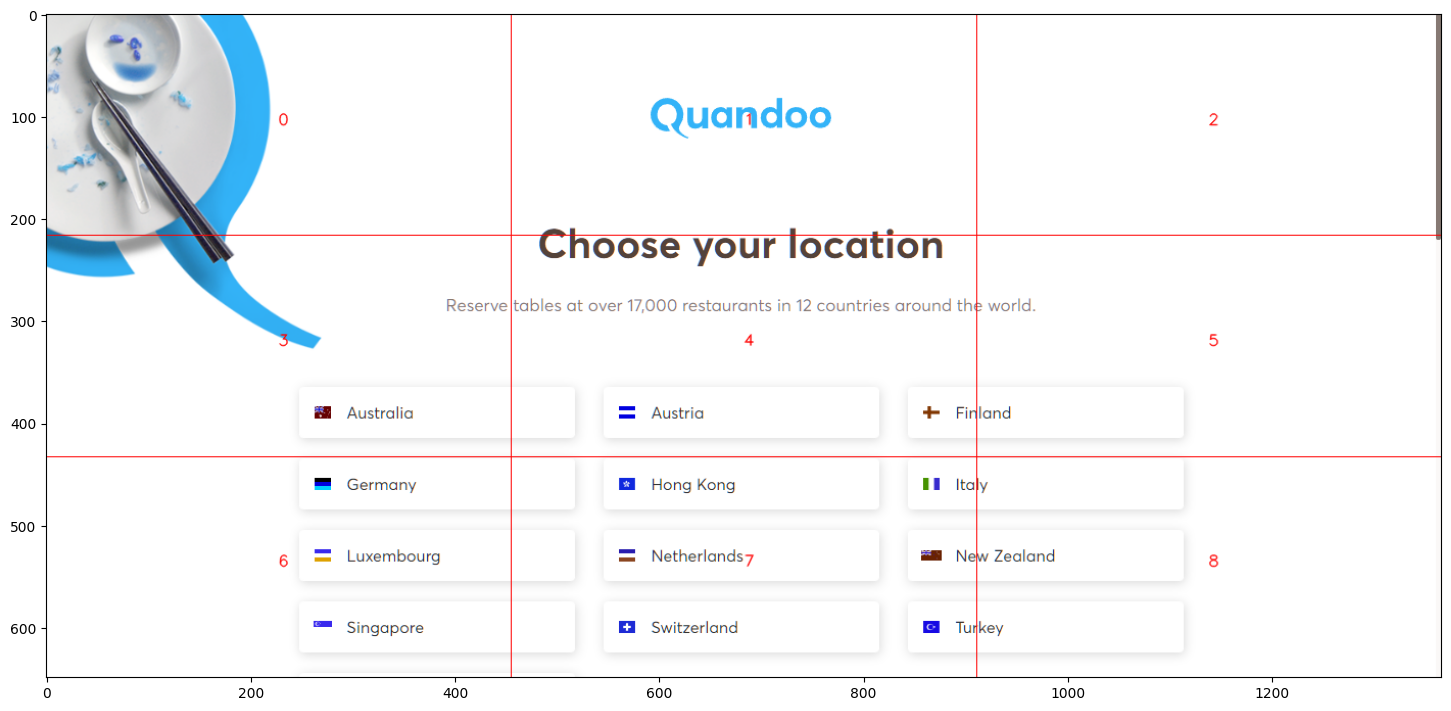

In [22]:
im = cv2.imread(screenshot_file)
font = cv2.FONT_HERSHEY_SIMPLEX 

draw_grid(im, (3,3), color=(255,0,0))

fig, axs = plt.subplots(1, 1, figsize=(18,18))
axs.imshow(im)

In [11]:
im.shape

(651, 1366, 3)

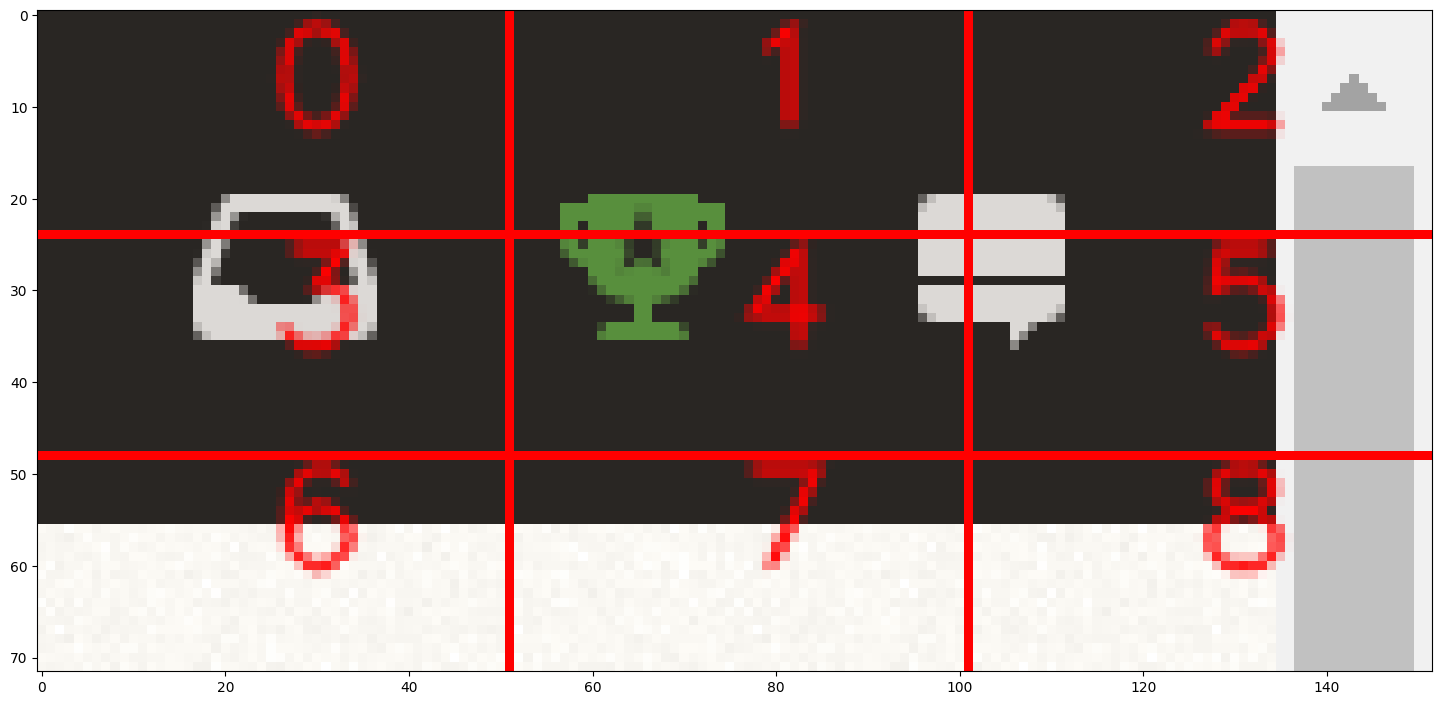

In [12]:
im = cv2.imread(screenshot_file)
font = cv2.FONT_HERSHEY_SIMPLEX 

s_y = im.shape[0] // 3
s_x = (im.shape[1] // 3) * 2
small_im = im[:s_y, s_x:]

s_y = small_im.shape[0] // 3
s_x = (small_im.shape[1] // 3) * 2
smaller_im = small_im[:s_y, s_x:]

draw_grid(smaller_im, (3,3), color=(255,0,0))

fig, axs = plt.subplots(1, 1, figsize=(18,18))
axs.imshow(smaller_im)

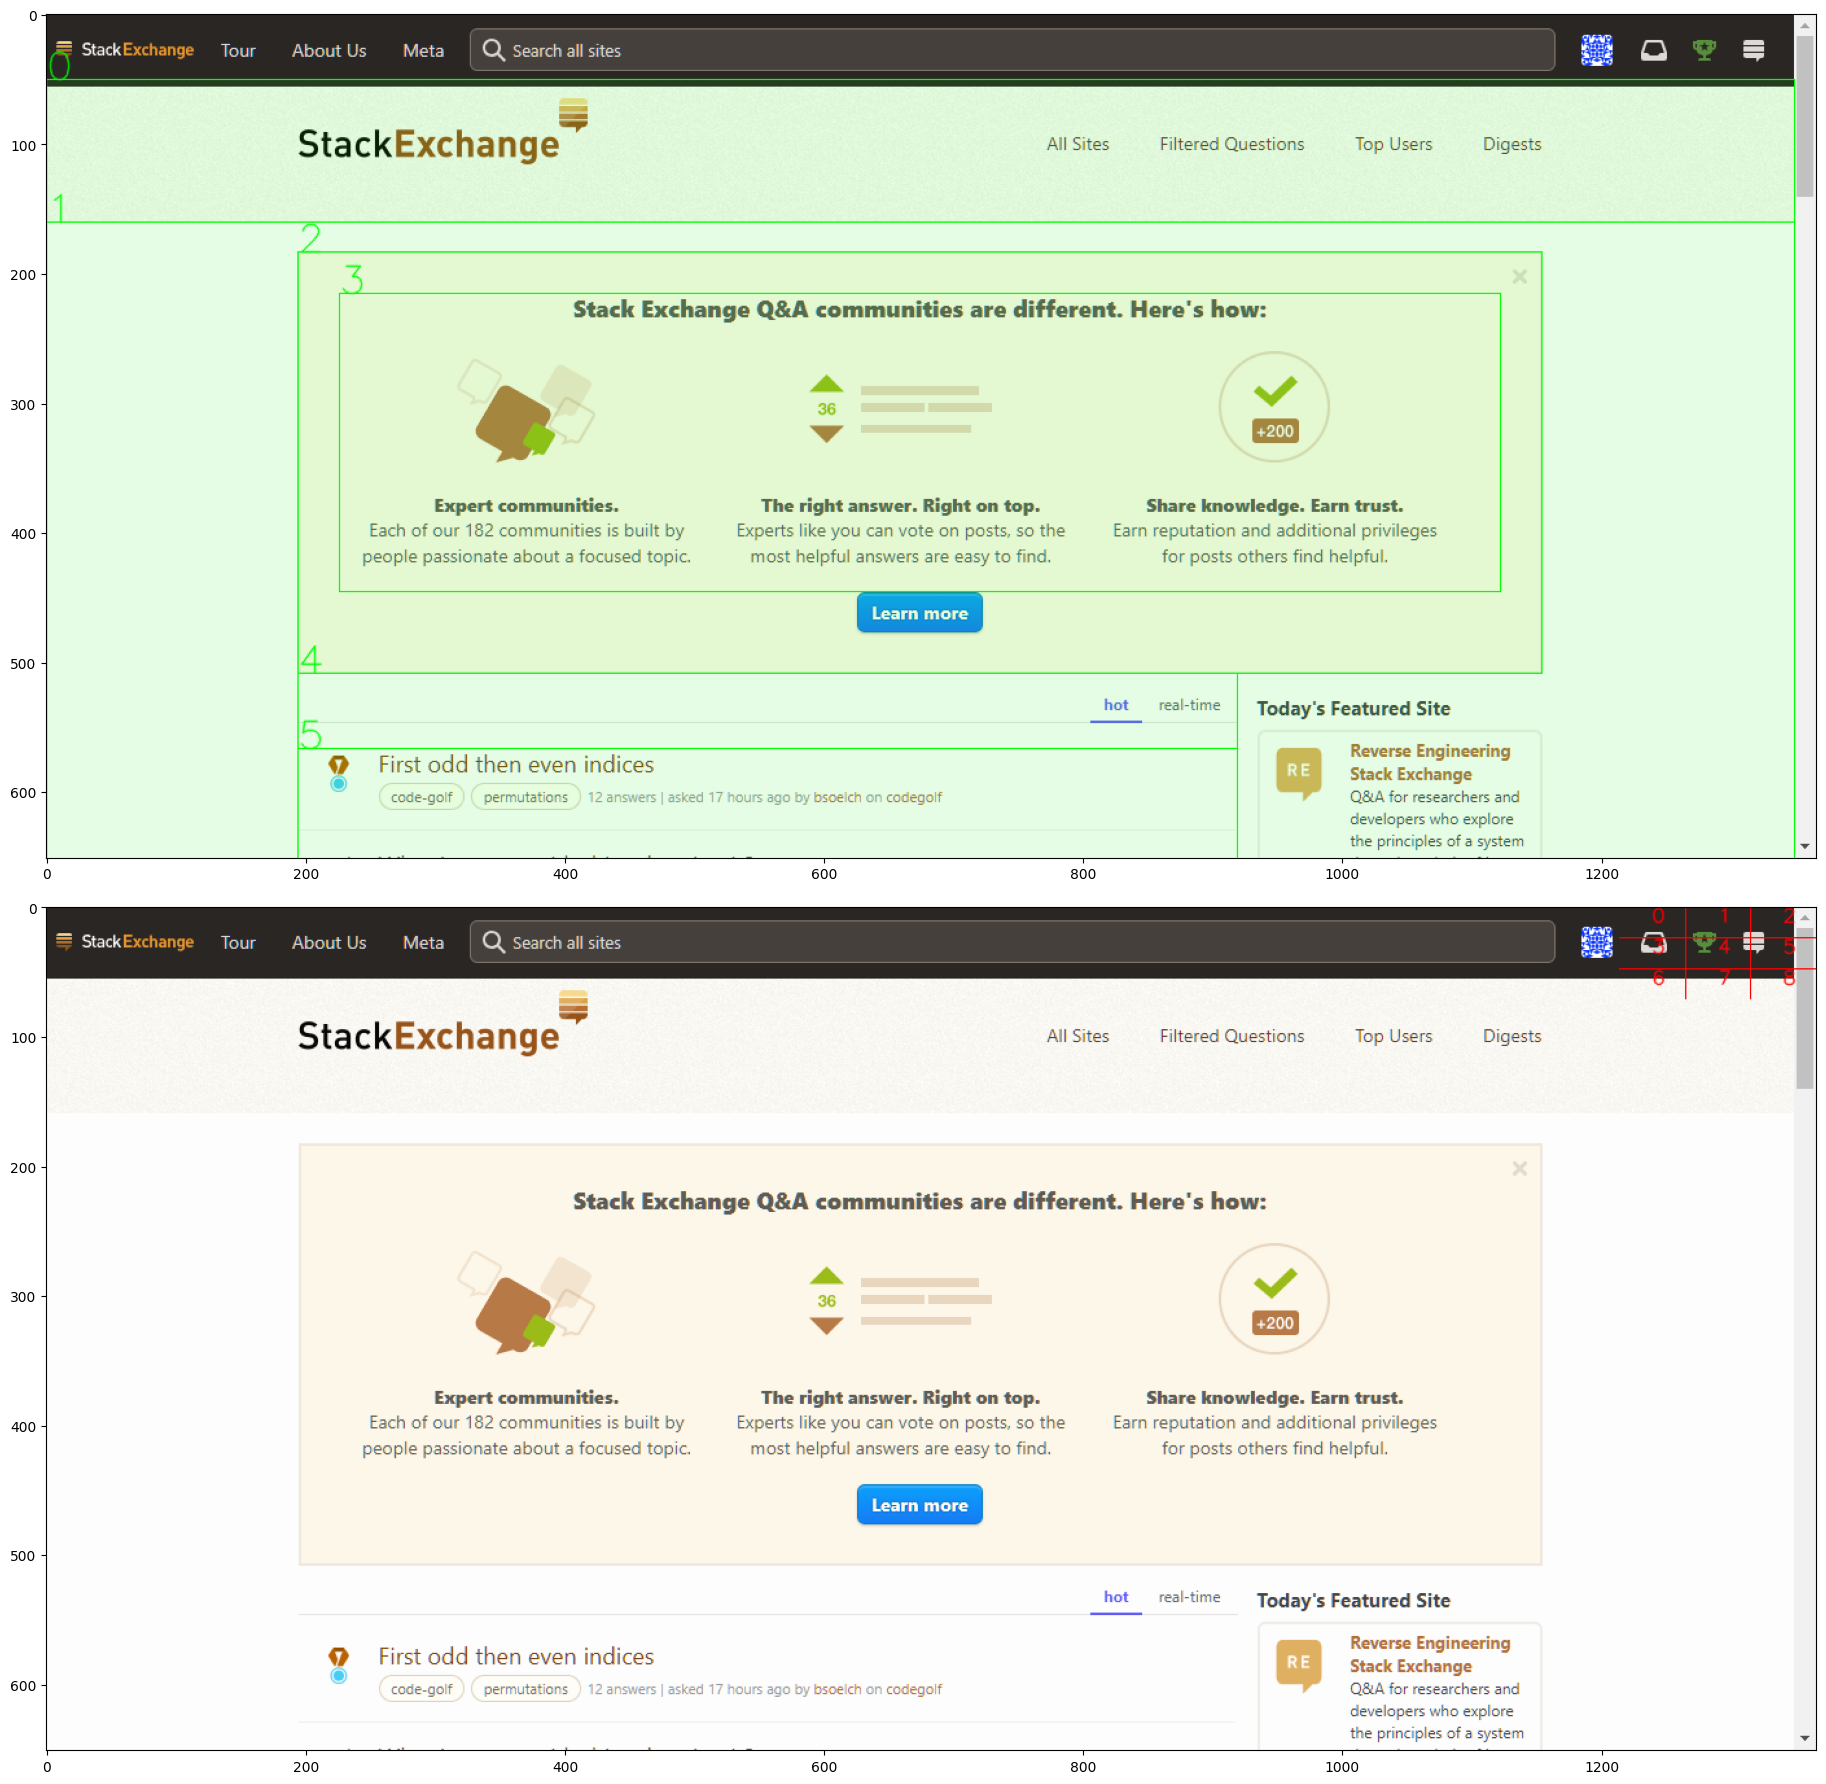

In [13]:
fig, axs = plt.subplots(2, 1, figsize=(18,18))
axs[0].imshow(high_lvl_im)
axs[1].imshow(im)
plt.tight_layout()

### WIP: build bounding boxes in non-covered areas

In [90]:
y_max = 651
x_max = 1366
is_covered = np.zeros((y_max, x_max))

for v in big_bbs_2.values():
    is_covered[int(v['top']):int(v['bottom']),int(v['left']):int(v['right'])] = 1

plt.imshow(is_covered)

# find boxes in small bbs that fill most area without (much) overlap
move_filled = is_covered.sum()
for k, v in small_bbs:
    new_filled = 

## Filter elements by removing duplicated ones based on text in html

In [256]:
# This only returns a certain type of text structure. 
# Tho, text in i.e. meta-content is not returned. How do we also include that?

def get_element_text(key):
    key_html = soup.find(attrs={"data-webtasks-id": key})
    if key_html is None:
        return None
    div_strs = '\n'.join([s for s in key_html.stripped_strings])
    return div_strs

In [15]:
keys = list(big_bbs_2.keys())

key_html = soup.find(attrs={"data-webtasks-id": keys[0]})
div_strs = '\n'.join([s for s in key_html.stripped_strings])
div_strs

"Tour\nAbout Us\nMeta\nLoading…\nWebtasks Navigator\n0\n+0\ncurrent community\nStack Exchange\nchat\nlog out\nMeta Stack Exchange\nyour communities\nedit\ncancel\nLaw\n1\nStack Overflow\n1\nTravel\n1\nAdd\nReset\nSave\nmore stack exchange communities\ncompany blog\nStack Exchange\nAll Sites\nFiltered Questions\nTop Users\nDigests\nStack Exchange Q&A communities are different. Here's how:\nExpert communities.\nEach of our\n182\ncommunities is built by people passionate about a focused topic.\nThe right answer. Right on top.\nExperts like you can vote on posts, so the most helpful answers are easy to find.\nShare knowledge. Earn trust.\nEarn reputation and additional privileges for posts others find helpful.\nLearn more\nhot\nreal-time\nFirst odd then even indices\ncode-golf\npermutations\n12 answers |\n                    asked 17 hours ago\nby\nbsoelch\non\ncodegolf\nWhat is wrong with this relay circuit?\ncircuit-analysis\ncircuit-design\nrelay\n6 answers |\n                    asked 

In [16]:
txt_dict = {k: get_element_text(k) for k in bboxes.keys()}
# not_nan_txt_dict = {k: v for k, v in txt_dict.items() if v is not None and len(v)>0}

In [17]:
# delete elements that contain the same text as others
seen_vals = []

filtered_txt_dict = {} 
for k, v in txt_dict.items():
    if not v in seen_vals \
        or v is None \
        or len(v) < 3:
        # TODO always chose smallest html here
        filtered_txt_dict[k] = v

    seen_vals.append(v)

In [18]:
len(filtered_txt_dict)

80

In [19]:
list(txt_dict.values())[77]

'Learn more'

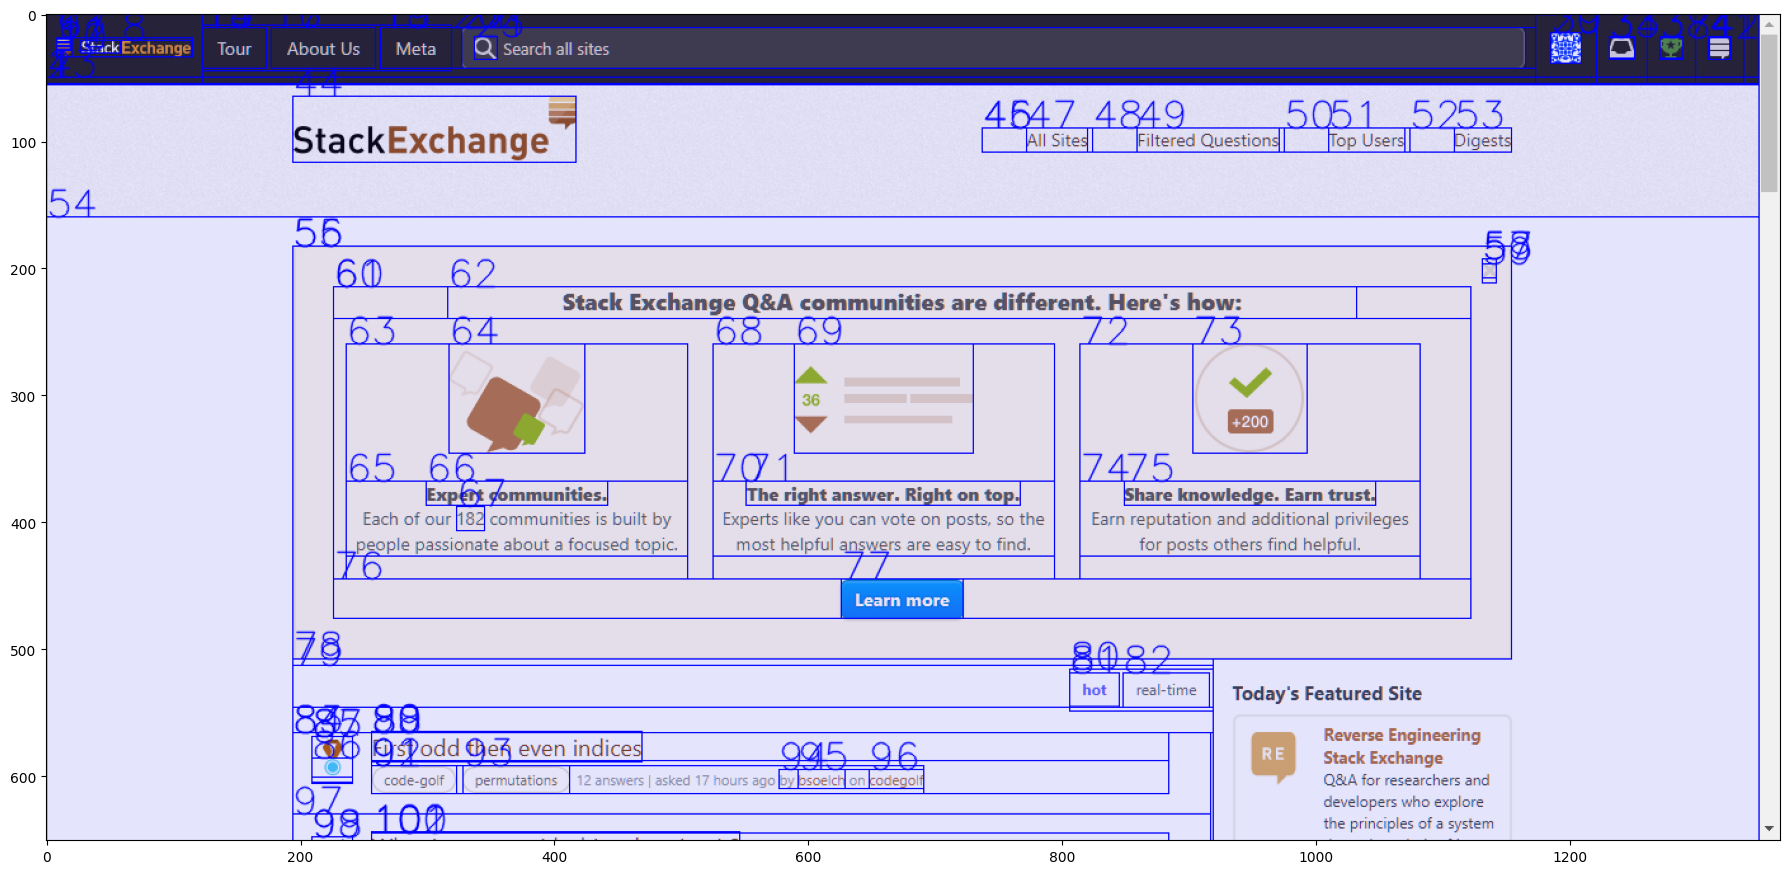

In [20]:
im = cv2.imread(screenshot_file)

filtered_im = im.copy()
filtered_count = 0

for k in txt_dict.keys():
    bb = bboxes[k]
    start_point = (int(bb['left']), int(bb['top']))
    end_point = (int(bb['right']), int(bb['bottom']))
    c = (0,0,255)
    cv2.rectangle(filtered_im, start_point, end_point, c, thickness)
    cv2.rectangle(overlay, start_point, end_point, c, -1)
    cv2.putText(filtered_im, str(filtered_count), start_point, font,  
                fontScale, c, thickness, cv2.LINE_AA) 
    filtered_count += 1

cv2.addWeighted(overlay, alpha, filtered_im, 1 - alpha, 0, filtered_im)

fig, axs = plt.subplots(1, 1, figsize=(18,9))
axs.imshow(filtered_im)
# axs[1].imshow(im)
plt.tight_layout()

# Only keep elements without further childs that also have a bounding box

In [24]:
def get_elements_with_n_childs(soup, n):
    small_elements = []
    for e in soup.find_all():
        childs = [c for c in e.children]
        l = len(childs)
        if l > n:
            continue

        if l == 1:
            try:
                l_2 = len([c for c in childs[0].children])
            except:
                l_2 = 0
            if l_2 > 0:
                continue

        small_elements.append(e)

    small_keys = [e.get("data-webtasks-id") for e in small_elements]
    small_keys = [k for k in small_keys if k in bboxes]
    return small_keys

def filter_parents(keys):
    e_txts = [soup.find(attrs={"data-webtasks-id": k}) for k in keys]
    child_keys = []
    for k, txt in zip(keys, e_txts):
        # only append if there is no other txt that contains this text
        if txt is None:
            continue
        
        has_child_txt = False
        for o_k, o_txt in zip(keys, e_txts):
            if k == o_k or o_txt is None or len(o_txt) < 1:
                continue
            if str(o_txt) in str(txt) and not o_txt == txt:
                has_child_txt = True
                break

        if not has_child_txt:
            child_keys.append(k)

    return child_keys

# TODO do opposite, to find k non-overlapping elements with most children

In [37]:
small_keys = get_elements_with_n_childs(soup, 3)
len(small_keys)

114

In [38]:
all_keys = [k for k in bboxes.keys()]
no_substring_keys = filter_parents(all_keys)
len(no_substring_keys)

88

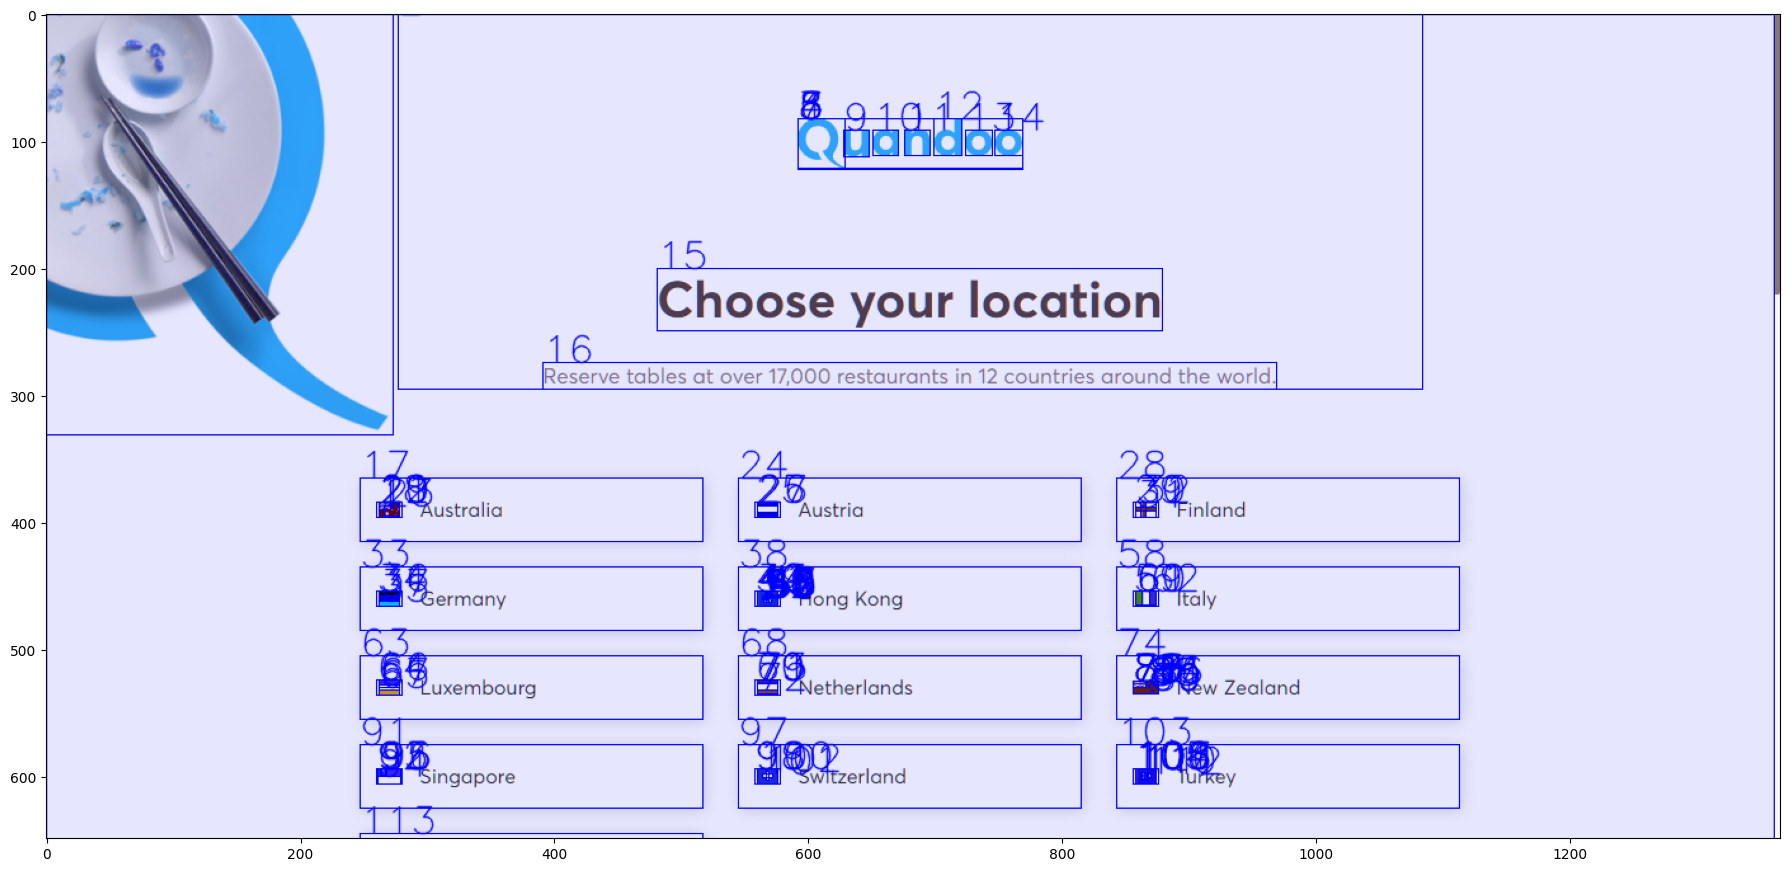

In [39]:
im = cv2.imread(screenshot_file)

filtered_im = im.copy()
filtered_count = 0

for k in small_keys:
    bb = bboxes[k]
    start_point = (int(bb['left']), int(bb['top']))
    end_point = (int(bb['right']), int(bb['bottom']))
    c = (0,0,255)
    cv2.rectangle(filtered_im, start_point, end_point, c, thickness)
    cv2.rectangle(overlay, start_point, end_point, c, -1)
    cv2.putText(filtered_im, str(filtered_count), start_point, font,  
                fontScale, c, thickness, cv2.LINE_AA) 
    filtered_count += 1

cv2.addWeighted(overlay, alpha, filtered_im, 1 - alpha, 0, filtered_im)

fig, axs = plt.subplots(1, 1, figsize=(18,9))
axs.imshow(filtered_im)
plt.tight_layout()

In [29]:
def filter_duplicates(keys):
    e_html = [soup.find(attrs={"data-webtasks-id": k}) for k in keys]

    # delete elements that contain the same text as others
    seen_vals = []
    unique_keys = []
    for k, v in zip(keys, e_html):
        if not v in seen_vals or v is None:
            seen_vals.append(v)
            unique_keys.append(k)

    return unique_keys

In [30]:
import bs4

max_depth = 5

def find_child_keys(element, depth_idx, highest_keys):
    if depth_idx >= max_depth:
        return
    for c in element.children:
        if not isinstance(c, bs4.element.NavigableString):
            highest_keys.append(c.get("data-webtasks-id"))
            find_child_keys(c, depth_idx+1, highest_keys)

highest_keys = []
find_child_keys(soup, 0, highest_keys)

highest_keys = [k for k in highest_keys if k in bboxes]
highest_keys = np.unique(highest_keys).tolist()
print(len(highest_keys))
highest_keys = filter_duplicates(highest_keys)
print(len(highest_keys))

7
7


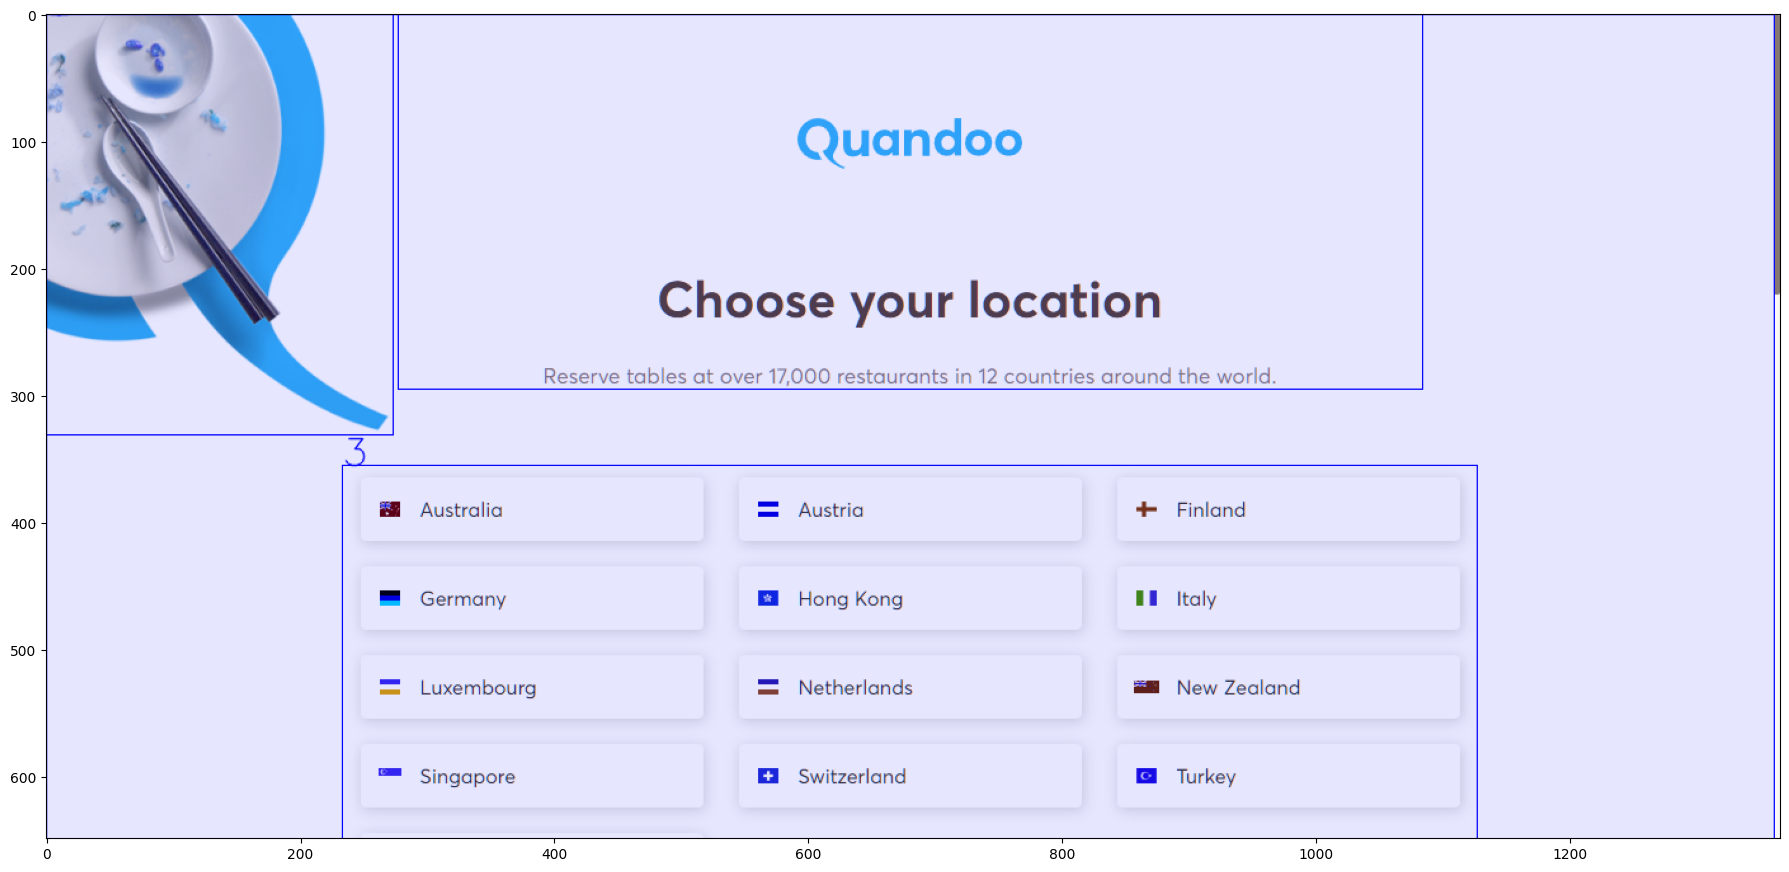

In [31]:
im = cv2.imread(screenshot_file)

filtered_im = im.copy()
filtered_count = 0

for k in highest_keys:
    bb = bboxes[k]
    start_point = (int(bb['left']), int(bb['top']))
    end_point = (int(bb['right']), int(bb['bottom']))
    c = (0,0,255)
    cv2.rectangle(filtered_im, start_point, end_point, c, thickness)
    cv2.rectangle(overlay, start_point, end_point, c, -1)
    cv2.putText(filtered_im, str(filtered_count), start_point, font,  
                fontScale, c, thickness, cv2.LINE_AA) 
    filtered_count += 1

cv2.addWeighted(overlay, alpha, filtered_im, 1 - alpha, 0, filtered_im)

fig, axs = plt.subplots(1, 1, figsize=(18,9))
axs.imshow(filtered_im)
plt.tight_layout()

In [ ]:
# test different filters on benchmark